# Finite Markov Decision Processes

This notebook develops the mathematical foundation of **finite Markov Decision Processes (MDPs)** and connects the equations to small computational examples.

## 1. Stochastic Processes

A **stochastic process** is a sequence of random variables that evolves over time. If $S_t$ denotes the state at time $t$, then a state sequence may be written as

$$
S_0,S_1,S_2,\ldots
$$

In the most general case, the distribution of the next state may depend on the entire history:

$$
P(S_{t+1}\mid S_0,S_1,\ldots,S_t).
$$

This can become difficult to model because the amount of relevant history grows with time.

A dynamic environment may be:

- **deterministic**, where a state and action determine the next outcome exactly, or
- **stochastic**, where outcomes are described by probability distributions.

In reinforcement learning, the interaction eventually includes states, actions, and rewards:

$$
S_0,A_0,R_1,S_1,A_1,R_2,S_2,A_2,R_3,\ldots
$$

## 2. The Markov Property

A process is **first-order Markov** when the current state contains all information from the past that is needed to predict the next state:

$$
\boxed{
P(S_{t+1}=s'\mid S_0,\ldots,S_t)
=
P(S_{t+1}=s'\mid S_t)
}
$$

Once $S_t$ is known, earlier states do not provide additional information about the distribution of $S_{t+1}$.

A higher-order process may require more recent history. For example, a second-order model could use

$$
P(S_{t+1}\mid S_t,S_{t-1}).
$$

A common strategy is to enlarge the state so that the new representation becomes first-order Markov. For example, define

$$
X_t=(S_t,S_{t-1}).
$$

Then the process can be modeled as

$$
P(X_{t+1}\mid X_t).
$$

### State representation

The Markov property is fundamentally a requirement on the **state representation**.

If position alone is not sufficient to predict a robot's next motion,

$$
S_t=(x_t,y_t,z_t),
$$

we may add velocity,

$$
S_t=(x_t,y_t,z_t,v_{x,t},v_{y,t},v_{z,t}),
$$

and, if needed, orientation and angular velocity.

The design goal is to include enough information for prediction without making the state unnecessarily large.

## 3. Stationary or Time-Homogeneous Dynamics

For the finite-MDP formulation used here, we assume the transition rule does not explicitly change with time.

For a Markov process,

$$
P(S_{t+1}=s'\mid S_t=s)
=
P(S_{k+1}=s'\mid S_k=s)
$$

for any applicable time indices $t$ and $k$.

This assumption is often called **time-homogeneous** dynamics. It is distinct from the idea of a stationary probability distribution.

If time itself changes the dynamics, one possible modeling choice is to include relevant time information in the state.

## 4. Transition Probabilities and Transition Matrix

For a finite Markov process,

$$
p(s'|s)
=
P(S_{t+1}=s'\mid S_t=s).
$$

For every current state $s$,

$$
\boxed{
\sum_{s'}p(s'|s)=1
}
$$

because the next state must be one of the possible states.

If

$$
\mathcal{S}=\{s_1,s_2,\ldots,s_n\},
$$

the transition matrix can be written as

$$
P=
\begin{bmatrix}
p(s_1|s_1) & p(s_2|s_1) & \cdots & p(s_n|s_1)\\
p(s_1|s_2) & p(s_2|s_2) & \cdots & p(s_n|s_2)\\
\vdots & \vdots & \ddots & \vdots\\
p(s_1|s_n) & p(s_2|s_n) & \cdots & p(s_n|s_n)
\end{bmatrix}.
$$

For time-homogeneous dynamics, the $k$-step transition matrix is

$$
\boxed{
P^{(k)}=P^k
}
$$

and its $(i,j)$ entry gives the probability of moving from state $s_i$ to state $s_j$ in $k$ steps.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P = np.array([
    [0.70, 0.20, 0.10],
    [0.10, 0.60, 0.30],
    [0.20, 0.20, 0.60]
])

print("Transition matrix P:")
print(P)
print("\nRow sums:", P.sum(axis=1))

print("\nTwo-step transition matrix P^2:")
print(np.round(np.linalg.matrix_power(P, 2), 3))

print("\nThree-step transition matrix P^3:")
print(np.round(np.linalg.matrix_power(P, 3), 3))

Transition matrix P:
[[0.7 0.2 0.1]
 [0.1 0.6 0.3]
 [0.2 0.2 0.6]]

Row sums: [1. 1. 1.]

Two-step transition matrix P^2:
[[0.53 0.28 0.19]
 [0.19 0.44 0.37]
 [0.28 0.28 0.44]]

Three-step transition matrix P^3:
[[0.437 0.312 0.251]
 [0.251 0.376 0.373]
 [0.312 0.312 0.376]]


## 5. From a Markov Process to a Markov Decision Process

A Markov process describes how states evolve.

A **Markov Decision Process** adds a decision maker. At time $t$, the agent observes $S_t$, chooses $A_t$, and the environment generates a reward and next state:

$$
\boxed{
S_t
\xrightarrow{A_t}
(R_{t+1},S_{t+1})
}
$$

Actions therefore influence both immediate rewards and future states.

## 6. The Agent–Environment Interface
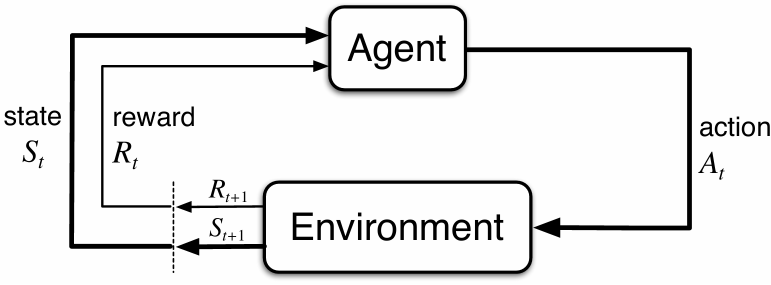

The **agent** is the learner and decision maker. Everything it interacts with is modeled as the **environment**.

At each discrete time step

$$
t=0,1,2,\ldots,
$$

the interaction is:

1. the agent observes $S_t$,
2. the agent chooses $A_t$,
3. the environment produces $R_{t+1}$,
4. the environment moves to $S_{t+1}$.

The resulting trajectory is

$$
\boxed{
S_0,A_0,R_1,S_1,A_1,R_2,S_2,A_2,R_3,\ldots
}
$$

For a finite MDP,

$$
S_t\in\mathcal{S},\qquad
A_t\in\mathcal{A}(S_t),\qquad
R_{t+1}\in\mathcal{R},
$$

where the state, action, and reward sets contain finitely many elements.

The agent–environment boundary is defined by the decision problem rather than by a physical boundary. For example, a controller may choose a motor command while the motor dynamics, robot body, sensors, and physical motion are modeled as part of the environment.

## 7. Finite MDP Dynamics

The complete one-step dynamics of a finite MDP are described by

$$
\boxed{
p(s',r|s,a)
=
P(S_{t+1}=s',R_{t+1}=r\mid S_t=s,A_t=a)
}
$$

This answers:

> If the agent is in state $s$ and takes action $a$, what is the probability of receiving reward $r$ and moving to state $s'$?

For every valid state-action pair,

$$
\boxed{
\sum_{s'\in\mathcal{S}}
\sum_{r\in\mathcal{R}}
p(s',r|s,a)=1
}
$$

because one of the possible $(s',r)$ outcomes must occur.

The Markov property for the MDP can be written as

$$
P(S_{t+1},R_{t+1}\mid S_0,A_0,\ldots,S_t,A_t)
=
P(S_{t+1},R_{t+1}\mid S_t,A_t).
$$

Given the current state and action, earlier states and actions do not change the one-step probability distribution.

## 8. Quantities Derived from the Dynamics Function

The four-argument dynamics function

$$
p(s',r|s,a)
$$

contains the complete one-step behavior of the environment. From it, we can derive several useful quantities.

The **state-transition probability** gives the probability of reaching next state $s'$ after taking action $a$ in state $s$. Since the reward can take different values, we sum over all possible rewards:

$$
p(s'|s,a)
=
\Pr\{S_{t+1}=s' \mid S_t=s, A_t=a\}
=
\sum_{r\in\mathcal{R}} p(s',r|s,a).
$$

The **expected reward for a state-action pair** gives the average immediate reward obtained when action $a$ is taken in state $s$. The expectation is computed over all possible next states and rewards:

$$
r(s,a)
=
\mathbb{E}[R_{t+1}\mid S_t=s, A_t=a]
=
\sum_{r\in\mathcal{R}} r
\sum_{s'\in\mathcal{S}} p(s',r|s,a)
=
\sum_{s'\in\mathcal{S}}
\sum_{r\in\mathcal{R}} rp(s',r|s,a).
$$

Sometimes the next state $s'$ is also known. In that case, the **expected reward for a state-action-next-state transition** is

$$
r(s,a,s')
=
\mathbb{E}[R_{t+1}\mid S_t=s, A_t=a, S_{t+1}=s']
=
\sum_{r\in\mathcal{R}}
r\,
\frac{p(s',r|s,a)}{p(s'|s,a)},
$$

for

$$
p(s'|s,a)>0.
$$

These quantities describe different views of the same environment dynamics:

- $p(s',r|s,a)$: probability of both the next state and reward,
- $p(s'|s,a)$: probability of the next state only,
- $r(s,a)$: expected immediate reward for a state-action pair,
- $r(s,a,s')$: expected reward when the next state is also specified.

# Worked Example 1: Recycling Robot
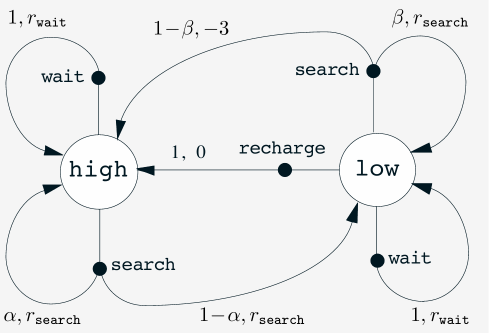

A mobile robot searches for empty cans while operating on a rechargeable battery.

The battery has two states:

$$
\mathcal{S}=\{\text{high},\text{low}\}.
$$

Available actions are

$$
\mathcal{A}(\text{high})
=
\{\text{search},\text{wait}\},
$$

and

$$
\mathcal{A}(\text{low})
=
\{\text{search},\text{wait},\text{recharge}\}.
$$

Searching gives expected reward $r_{\text{search}}$ and waiting gives $r_{\text{wait}}$, with

$$
r_{\text{search}}>r_{\text{wait}}.
$$

Transition rules:

- from `high`, `search` stays `high` with probability $\alpha$ and moves to `low` with probability $1-\alpha$;
- from `low`, `search` stays `low` with probability $\beta$;
- with probability $1-\beta$, searching from `low` depletes the battery, the robot is rescued, receives reward $-3$, and returns to `high`;
- `wait` leaves the battery state unchanged;
- `recharge` deterministically moves `low` to `high` with reward $0$.

This is a finite MDP because the state, action, and reward sets are finite.

The label on each environment transition represents

$$
\bigl(p(s'|s,a),\;r(s,a,s')\bigr).
$$

For example,

$$
(1-\beta,-3)
$$

means that after `search` in the `low` state, the robot is rescued and moves to `high` with probability $1-\beta$, receiving reward $-3$.

In [ ]:
transition_table = pd.DataFrame({
    "State s": [
        "high", "high",
        "low", "low",
        "high", "high",
        "low", "low",
        "low", "low"
    ],
    "Action a": [
        "search", "search",
        "search", "search",
        "wait", "wait",
        "wait", "wait",
        "recharge", "recharge"
    ],
    "Next state s'": [
        "high", "low",
        "high", "low",
        "high", "low",
        "high", "low",
        "high", "low"
    ],
    "p(s'|s,a)": [
        "α", "1-α",
        "1-β", "β",
        "1", "0",
        "0", "1",
        "1", "0"
    ],
    "r(s,a,s')": [
        "r_search", "r_search",
        "-3", "r_search",
        "r_wait", "—",
        "—", "r_wait",
        "0", "—"
    ]
})

transition_table

,State s,Action a,Next state s',"p(s'|s,a)","r(s,a,s')"
0,high,search,high,α,r_search
1,high,search,low,1-α,r_search
2,low,search,high,1-β,-3
3,low,search,low,β,r_search
4,high,wait,high,1,r_wait
5,high,wait,low,0,—
6,low,wait,high,0,—
7,low,wait,low,1,r_wait
8,low,recharge,high,1,0
9,low,recharge,low,0,—


In [ ]:
alpha = 0.8
beta = 0.6

transition_probabilities = {
    ("high", "search"): {"high": alpha, "low": 1 - alpha},
    ("high", "wait"): {"high": 1.0, "low": 0.0},
    ("low", "search"): {"high": 1 - beta, "low": beta},
    ("low", "wait"): {"high": 0.0, "low": 1.0},
    ("low", "recharge"): {"high": 1.0, "low": 0.0}
}

for (state, action), probabilities in transition_probabilities.items():
    total = sum(probabilities.values())
    print(f"sum_s' p(s' | {state}, {action}) = {total:.1f}")

sum_s' p(s' | high, search) = 1.0
sum_s' p(s' | high, wait) = 1.0
sum_s' p(s' | low, search) = 1.0
sum_s' p(s' | low, wait) = 1.0
sum_s' p(s' | low, recharge) = 1.0


## 9. The MDP Tuple

A finite MDP is commonly represented as

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

where:

* $\mathcal{S}$: state space
* $\mathcal{A}$: action space
* $P(s'|s,a)$: transition probability
* $R(s,a,s')$: immediate reward
* $\gamma$: discount factor

An initial-state distribution may also be specified:

$$
\rho_0(s)=P(S_0=s)
$$

For episodic tasks, terminal states are defined as well.


## 10. A 7×7 GridWorld MDP

Both deterministic and stochastic examples use the same environment:

- Start: `(0, 0)`
- Goal: `(6, 6)`
- Obstacles: `(2, 2)`, `(3, 3)`, `(4, 4)`, `(5, 2)`, `(1, 5)`
- Actions: `Up`, `Down`, `Left`, `Right`
- Regular move reward: `-1`
- Obstacle attempt: stay in the current state and receive `-5`
- Goal reward: `+10`
- Boundary attempt: stay in the current state and receive `-1`

In the stochastic version, the intended direction occurs with probability 0.80 and the two perpendicular slip directions each occur with probability 0.10.

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
np.random.seed(SEED)

In [ ]:
class GridworldMDP:
    def __init__(self, stochastic=False, gamma=0.9, seed=42):
        self.size = 7
        self.gamma = gamma
        self.stochastic = stochastic
        self.rng = np.random.default_rng(seed)

        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.action_space = ("Up", "Down", "Left", "Right")

        self.state_space = [
            (r, c)
            for r in range(self.size)
            for c in range(self.size)
            if (r, c) not in self.obstacles
        ]

        self.state_to_index = {s: i for i, s in enumerate(self.state_space)}
        self.index_to_state = {i: s for s, i in self.state_to_index.items()}

        self.slip_actions = {
            "Up": ("Left", "Right"),
            "Down": ("Right", "Left"),
            "Left": ("Down", "Up"),
            "Right": ("Up", "Down"),
        }

        self.state = self.start_state

    def reset(self, state=None, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        if state is None:
            state = self.start_state

        if state not in self.state_space:
            raise ValueError("Invalid reset state.")

        self.state = state
        return state

    def _move(self, state, action):
        if state == self.goal_state:
            return self.goal_state, 0, True

        r, c = state

        if action == "Up":
            candidate = (max(r - 1, 0), c)
        elif action == "Down":
            candidate = (min(r + 1, self.size - 1), c)
        elif action == "Left":
            candidate = (r, max(c - 1, 0))
        elif action == "Right":
            candidate = (r, min(c + 1, self.size - 1))
        else:
            raise ValueError("Invalid action.")

        if candidate in self.obstacles:
            return state, -5, False

        if candidate == self.goal_state:
            return candidate, 10, True

        return candidate, -1, False

    def transition_distribution(self, state, action):
        if state == self.goal_state:
            return [(1.0, self.goal_state, 0, True)]

        if not self.stochastic:
            ns, r, done = self._move(state, action)
            return [(1.0, ns, r, done)]

        slip_1, slip_2 = self.slip_actions[action]
        outcomes = [
            (0.80, action),
            (0.10, slip_1),
            (0.10, slip_2),
        ]

        aggregate = defaultdict(float)

        for probability, actual_action in outcomes:
            ns, r, done = self._move(state, actual_action)
            aggregate[(ns, r, done)] += probability

        return [
            (p, ns, r, done)
            for (ns, r, done), p in aggregate.items()
        ]

    def step(self, action):
        distribution = self.transition_distribution(self.state, action)
        probabilities = [x[0] for x in distribution]
        i = self.rng.choice(len(distribution), p=probabilities)

        probability, ns, reward, done = distribution[i]
        self.state = ns

        return ns, reward, done, {"sampled_probability": probability}

    def plot(self, title):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, 6.5)
        ax.set_ylim(6.5, -0.5)

        ax.set_xticks(range(7))
        ax.set_yticks(range(7))
        ax.set_xticks(np.arange(-0.5, 7, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 7, 1), minor=True)
        ax.grid(which="minor", linewidth=1)

        for r in range(7):
            for c in range(7):
                state = (r, c)

                if state in self.obstacles:
                    label = "X"
                elif state == self.start_state:
                    label = "S"
                elif state == self.goal_state:
                    label = "G"
                else:
                    label = ""

                if label:
                    ax.text(c, r, label, ha="center", va="center", fontsize=14)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(title)
        plt.show()

Valid states: 44
Actions: ('Up', 'Down', 'Left', 'Right')
Discount factor: 0.9


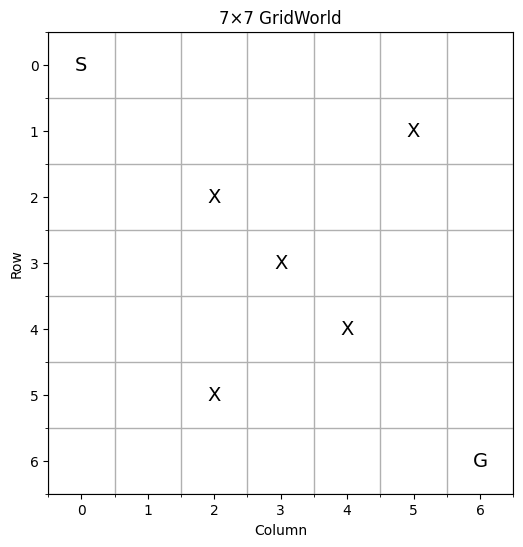

In [ ]:
det_env = GridworldMDP(stochastic=False, seed=SEED)
stoch_env = GridworldMDP(stochastic=True, seed=SEED)

print("Valid states:", len(det_env.state_space))
print("Actions:", det_env.action_space)
print("Discount factor:", det_env.gamma)

det_env.plot("7×7 GridWorld")

## 10.1. State Space $\mathcal{S}$

A state should contain the information needed for future decisions.

Here, the state is the agent's location:

$$
s=(row,column)
$$

Obstacle cells are not valid states because the agent cannot occupy them.

In [ ]:
print("First 12 states:")
print(det_env.state_space[:12])
print("\nNumber of valid states:", len(det_env.state_space))

First 12 states:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4)]

Number of valid states: 44


## 10.2. Action Space $\mathcal{A}$

The action space is

$$
\mathcal{A}
=
\{\text{Up},\text{Down},\text{Left},\text{Right}\}
$$

In this environment, every non-terminal state uses the same action set. In other MDPs, the valid action set can depend on the state, written $\mathcal{A}(s)$.


In [ ]:
for action in det_env.action_space:
    print(action)

Up
Down
Left
Right


## 10.3. Transition Model \(P(s'|s,a)\)

The transition model gives the probability of arriving in \(s'\) after taking action \(a\) in state \(s\):

$$
P(s'|s,a)
=
P(S_{t+1}=s'\mid S_t=s,A_t=a)
$$

For each state-action pair,

$$
\sum_{s'} P(s'|s,a)=1
$$

### 10.4. Deterministic Transition

In [ ]:
state = (4, 1)
action = "Up"

for probability, next_state, reward, done in det_env.transition_distribution(state, action):
    print(
        f"P={probability:.2f} -> next_state={next_state}, "
        f"reward={reward}, done={done}"
    )

P=1.00 -> next_state=(3, 1), reward=-1, done=False


### 10.5 Stochastic Transition

In [ ]:
distribution = stoch_env.transition_distribution(state, action)

for probability, next_state, reward, done in sorted(distribution):
    print(
        f"P={probability:.2f} -> next_state={next_state}, "
        f"reward={reward}, done={done}"
    )

print("Probability sum:", sum(x[0] for x in distribution))

P=0.10 -> next_state=(4, 0), reward=-1, done=False
P=0.10 -> next_state=(4, 2), reward=-1, done=False
P=0.80 -> next_state=(3, 1), reward=-1, done=False
Probability sum: 1.0


A deterministic MDP has one realized next state for each state-action pair. A stochastic MDP can assign nonzero probability to several next states.

# 11. Goals, Rewards and Returns


The immediate reward can be written as

$$
R(s,a,s')
$$

or as an expected reward

$$
r(s,a)
=
\mathbb{E}[R_{t+1}\mid S_t=s,A_t=a]
$$

Reward and return are different:

- **reward:** immediate feedback
- **return:** accumulated future reward

# 11.1. Goals and Rewards

The purpose of the agent is represented by a numerical **reward** signal.

At every step,

$$
R_{t+1}\in\mathcal{R}.
$$

The reward evaluates the immediate consequence of the agent's action, but the objective in reinforcement learning is generally **long-term cumulative reward**, not simply the next reward.

The reward should describe **what the agent should achieve**, not prescribe how it should achieve it.

Examples:

- robot navigation: $-1$ per step until the goal is reached,
- recycling: positive reward for collecting a can,
- games: positive reward for winning and negative reward for losing,
- manufacturing control: a reward may combine throughput, delay, congestion, or resource cost.

# 11.2. Return and Episodic Tasks

The **return** $G_t$ summarizes the future rewards following time $t$.

For an episode terminating at time $T$,

$$
\boxed{
G_t
=
R_{t+1}+R_{t+2}+\cdots+R_T
}
$$

or equivalently,

$$
\boxed{
G_t
=
\sum_{k=0}^{T-t-1}R_{t+k+1}
}
$$

An **episodic task** naturally breaks into repeated finite interactions.

An episode has the form

$$
S_0,A_0,R_1,S_1,A_1,R_2,\ldots,S_T.
$$

The final state is a **terminal state**.

The termination time $T$ can vary from episode to episode.

# 11.3. Continuing Tasks and Discounted Return

Some interactions do not naturally terminate. These are **continuing tasks**.

If

$$
T=\infty,
$$

the undiscounted sum

$$
R_{t+1}+R_{t+2}+\cdots
$$

may diverge.

A common objective is therefore the **discounted return**:

$$
\boxed{
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\cdots
}
$$

or

$$
\boxed{
G_t
=
\sum_{k=0}^{\infty}\gamma^kR_{t+k+1}
}
$$

where

$$
0\leq\gamma\leq1
$$

is the **discount factor**.

Interpretation:

- $\gamma=0$: only the immediate reward matters;
- $\gamma$ close to $1$: future rewards matter strongly.

For bounded rewards, if $0\leq\gamma<1$, the discounted return is finite.

## 11.4 Why discounting can keep the return finite

Assume rewards are bounded:

$$
|R_t|\leq R_{\max}.
$$

Then

$$
|G_t|
\leq
R_{\max}
+
\gamma R_{\max}
+
\gamma^2R_{\max}
+\cdots.
$$

Factor out $R_{\max}$:

$$
|G_t|
\leq
R_{\max}
\left(
1+\gamma+\gamma^2+\cdots
\right).
$$

For $0\leq\gamma<1$,

$$
1+\gamma+\gamma^2+\cdots
=
\frac{1}{1-\gamma}.
$$

Therefore,

$$
\boxed{
|G_t|
\leq
\frac{R_{\max}}{1-\gamma}
}
$$

## 11.5 Recursive relationship of the return

Start from

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\gamma^3R_{t+4}
+\cdots.
$$

Separate the first reward:

$$
G_t
=
R_{t+1}
+
\left(
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\gamma^3R_{t+4}
+\cdots
\right).
$$

Factor $\gamma$:

$$
G_t
=
R_{t+1}
+
\gamma
\left(
R_{t+2}
+
\gamma R_{t+3}
+
\gamma^2R_{t+4}
+\cdots
\right).
$$

The expression in parentheses is exactly $G_{t+1}$:

$$
G_{t+1}
=
R_{t+2}
+
\gamma R_{t+3}
+
\gamma^2R_{t+4}
+\cdots.
$$

Hence,

$$
\boxed{
G_t=R_{t+1}+\gamma G_{t+1}
}
$$



## 11.6 Average reward as an alternative continuing objective

Another continuing-task objective is the long-run average reward:

$$
\boxed{
\bar r
=
\lim_{T\to\infty}
\frac{1}{T}
\mathbb{E}
\left[
\sum_{t=0}^{T-1}R_{t+1}
\right]
}
$$

This is an alternative to discounted return and is useful when long-run reward rate is the quantity of interest.

In [ ]:
def expected_reward(env, state, action, print_calc=False):
    total_reward = 0.0
    if print_calc:
        print(f"Calculating expected reward for state={{state}}, action={{action}}:")
    for p, _, reward, _ in env.transition_distribution(state, action):
        if print_calc:
            print(f"  P={p:.2f} * Reward={reward} = {p * reward:.3f}")
        total_reward += p * reward
    if print_calc:
        print(f"  Total Expected Reward = {total_reward:.3f}")
    return total_reward

state = (2, 1)
action = "Right"

print("Deterministic expected reward:")
expected_reward(det_env, state, action, print_calc=True)

print("\nStochastic expected reward:")
expected_reward(stoch_env, state, action, print_calc=True)

Deterministic expected reward:
Calculating expected reward for state={state}, action={action}:
  P=1.00 * Reward=-5 = -5.000
  Total Expected Reward = -5.000

Stochastic expected reward:
Calculating expected reward for state={state}, action={action}:
  P=0.80 * Reward=-5 = -4.000
  P=0.10 * Reward=-1 = -0.100
  P=0.10 * Reward=-1 = -0.100
  Total Expected Reward = -4.200


-4.199999999999999

In [ ]:
def discounted_return(rewards, gamma, print_calc=False):
    total_return = 0.0
    if print_calc:
        print(f"Calculating discounted return with gamma={gamma}:")
    for k, reward in enumerate(rewards):
        term = (gamma ** k) * reward
        if print_calc:
            print(f"  Reward at k={k}: {reward}, gamma^k={gamma**k:.3f}, Term={term:.3f}")
        total_return += term
    if print_calc:
        print(f"  Total Discounted Return = {total_return:.3f}")
    return total_return

rewards = [row[3] for row in trajectory]

print("Observed rewards:", rewards)

for gamma in [0.0, 0.5, 0.9, 1.0]:
    print(f"\ngamma={gamma:.1f} ->")
    discounted_return(rewards, gamma, print_calc=True)

Observed rewards: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 10]

gamma=0.0 ->
Calculating discounted return with gamma=0.0:
  Reward at k=0: -1, gamma^k=1.000, Term=-1.000
  Reward at k=1: -1, gamma^k=0.000, Term=-0.000
  Reward at k=2: -1, gamma^k=0.000, Term=-0.000
  Reward at k=3: -1, gamma^k=0.000, Term=-0.000
  Reward at k=4: -1, gamma^k=0.000, Term=-0.000
  Reward at k=5: -1, gamma^k=0.000, Term=-0.000
  Reward at k=6: -1, gamma^k=0.000, Term=-0.000
  Reward at k=7: -1, gamma^k=0.000, Term=-0.000
  Reward at k=8: -1, gamma^k=0.000, Term=-0.000
  Reward at k=9: -1, gamma^k=0.000, Term=-0.000
  Reward at k=10: -1, gamma^k=0.000, Term=-0.000
  Reward at k=11: 10, gamma^k=0.000, Term=0.000
  Total Discounted Return = -1.000

gamma=0.5 ->
Calculating discounted return with gamma=0.5:
  Reward at k=0: -1, gamma^k=1.000, Term=-1.000
  Reward at k=1: -1, gamma^k=0.500, Term=-0.500
  Reward at k=2: -1, gamma^k=0.250, Term=-0.250
  Reward at k=3: -1, gamma^k=0.125, Term=-0.125
  Reward 

## 12. Initial-State Distribution $\rho_0$

An MDP can specify the probability of starting in each state:

$$
\rho_0(s)=P(S_0=s)
$$

Here the start is fixed:

$$
\rho_0((0,0))=1
$$

and all other states have probability $0$.


In [ ]:
rho_0 = {
    state: 1.0 if state == det_env.start_state else 0.0
    for state in det_env.state_space
}

print("rho_0((0,0)) =", rho_0[(0, 0)])
print("rho_0((1,0)) =", rho_0[(1, 0)])

rho_0((0,0)) = 1.0
rho_0((1,0)) = 0.0


# 13. Terminal Stare, Episodic and Continuing Tasks

so, An episodic task has a natural end. For example, in this gridworld environment, reaching (6, 6) ends the episode.

A continuing task has no natural terminal point, such as long-running process control or resource allocation.

For an episodic task, we could explicitly index episodes:

$$
S_{t,i},\quad A_{t,i},\quad R_{t,i},
$$

where $i$ is the episode number.

In most derivations, the episode index is unnecessary, so we write simply

$$
S_t,\quad A_t,\quad R_t.
$$

## Absorbing terminal state

An episodic task can be represented as if it continues forever by introducing an absorbing terminal state.

Once entered,

$$
P(S_{t+1}=s_{\text{terminal}}\mid S_t=s_{\text{terminal}})=1
$$

and all future rewards are zero:

$$
R_{t+1}=0.
$$

For example,

$$
S_0
\xrightarrow{R_1=1}
S_1
\xrightarrow{R_2=1}
S_2
\xrightarrow{R_3=1}
S_{\text{terminal}}
$$

can be extended as

$$
S_{\text{terminal}}
\xrightarrow{R_4=0}
S_{\text{terminal}}
\xrightarrow{R_5=0}
S_{\text{terminal}}
\rightarrow\cdots.
$$

Thus,

$$
1+1+1
=
1+1+1+0+0+\cdots.
$$

For an episode ending at $T$, the discounted return can be written as

$$
\boxed{
G_t
=
\sum_{k=t+1}^{T}
\gamma^{k-t-1}R_k
}
$$

because:

- at $k=t+1$, the exponent is $0$ and the term is $R_{t+1}$;
- at $k=t+2$, the exponent is $1$ and the term is $\gamma R_{t+2}$;
- at $k=t+3$, the exponent is $2$ and the term is $\gamma^2R_{t+3}$.

Therefore,

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots
+\gamma^{T-t-1}R_T.
$$



# Worked Example 2: Pole Balancing

A cart moves along a track with a pole attached by a hinge. The agent applies forces to keep the pole upright.

A failure occurs when the pole tilts too far or the cart leaves the allowed track.

## Episodic formulation

Treat each balancing attempt as one episode.

Give reward

$$
R_{t+1}=+1
$$

for every successful time step.

If failure occurs after $K$ successful steps, then with no discounting,

$$
G_t
=
\underbrace{1+1+\cdots+1}_{K\text{ rewards}}
=
\boxed{K}.
$$

Maximizing return therefore means keeping the pole balanced for as many steps as possible.

## Continuing formulation

Instead, reset the pole after failure and continue indefinitely.

Use

$$
R_{t+1}
=
\begin{cases}
-1, & \text{if failure occurs},\\
0, & \text{otherwise}.
\end{cases}
$$

Suppose the failure penalty is received at $R_{t+K}$. Then

$$
G_t
=
0+\gamma(0)+\cdots+\gamma^{K-1}(-1)
=
\boxed{-\gamma^{K-1}}.
$$

For $0<\gamma<1$, delaying failure makes this negative return closer to zero, and therefore larger.

Both formulations encourage the same behavior: keep the pole balanced as long as possible.

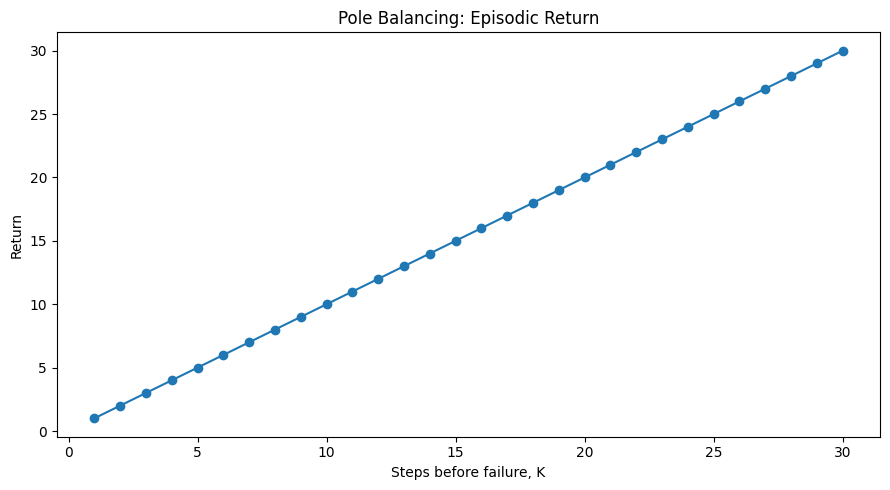

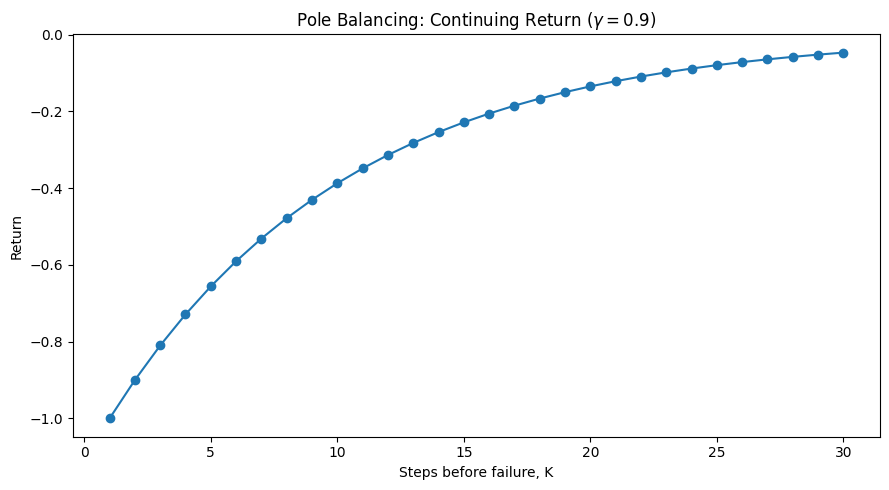

In [ ]:
gamma = 0.9
K = np.arange(1, 31)

episodic_return = K
continuing_return = -(gamma ** (K - 1))

plt.figure(figsize=(9, 5))
plt.plot(K, episodic_return, marker="o")
plt.xlabel("Steps before failure, K")
plt.ylabel("Return")
plt.title("Pole Balancing: Episodic Return")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(K, continuing_return, marker="o")
plt.xlabel("Steps before failure, K")
plt.ylabel("Return")
plt.title(r"Pole Balancing: Continuing Return ($\gamma=0.9$)")
plt.tight_layout()
plt.show()

# 14. Policies

A **policy** defines how the agent selects actions.

For a stochastic policy,

$$
\boxed{
\pi(a|s)
=
P(A_t=a\mid S_t=s)
}
$$

and for every state,

$$
\boxed{
\sum_{a\in\mathcal{A}(s)}
\pi(a|s)=1.
}
$$

A deterministic policy chooses one action with probability one:

$$
A_t=\pi(S_t).
$$

Example:

$$
\pi(\text{search}|\text{high})=0.8,
\qquad
\pi(\text{wait}|\text{high})=0.2.
$$

The policy describes **how the agent acts**, while

$$
p(s',r|s,a)
$$

describes **how the environment responds**.

In [ ]:
def uniform_random_policy(env, state):
    return {
        action: 1.0 / len(env.action_space)
        for action in env.action_space
    }

def simple_deterministic_policy(env, state):
    if state == env.goal_state:
        return None

    if state[0] < env.goal_state[0]:
        return "Down"

    return "Right"

state = (3, 1)

print("Uniform random policy:")
print(uniform_random_policy(det_env, state))

print("\nDeterministic policy:")
print(simple_deterministic_policy(det_env, state))

Uniform random policy:
{'Up': 0.25, 'Down': 0.25, 'Left': 0.25, 'Right': 0.25}

Deterministic policy:
Down


## Policy Randomness vs. Environment Randomness

Two different probability mechanisms may exist.

### Policy stochasticity

The agent randomizes over actions:

$$
\pi(a|s)
$$

### Transition stochasticity

The environment randomizes over next states:

$$
P(s'|s,a)
$$

A deterministic policy can therefore operate in a stochastic environment.

In [ ]:
print("Demonstrating both Policy Stochasticity and Transition Stochasticity:")
state_to_evaluate = (3, 3) # An arbitrary state

# Policy Stochasticity: Agent chooses actions probabilistically
print(f"\nPolicy \u03c0(a|s) for state {state_to_evaluate} (using uniform_random_policy):")
policy_probabilities = uniform_random_policy(stoch_env, state_to_evaluate)
for action, prob in policy_probabilities.items():
    print(f"  P(Action={action}|State={state_to_evaluate}) = {prob:.2f}")

# Transition Stochasticity: Environment's response to each action is probabilistic
print("\nTransition P(s',r|s,a) for each possible action:")
for action, action_prob in policy_probabilities.items():
    if action_prob > 0: # Only consider actions with non-zero policy probability
        print(f"-- If agent chooses Action: {action} (with policy probability {action_prob:.2f}) --")
        environment_outcomes = stoch_env.transition_distribution(state_to_evaluate, action)
        for p_env, next_s, reward, done in sorted(environment_outcomes):
            print(f"  Env Outcome: P={p_env:.2f} -> Next State={next_s}, Reward={reward}, Done={done}")

Demonstrating both Policy Stochasticity and Transition Stochasticity:

Policy π(a|s) for state (3, 3) (using uniform_random_policy):
  P(Action=Up|State=(3, 3)) = 0.25
  P(Action=Down|State=(3, 3)) = 0.25
  P(Action=Left|State=(3, 3)) = 0.25
  P(Action=Right|State=(3, 3)) = 0.25

Transition P(s',r|s,a) for each possible action:
-- If agent chooses Action: Up (with policy probability 0.25) --
  Env Outcome: P=0.10 -> Next State=(3, 2), Reward=-1, Done=False
  Env Outcome: P=0.10 -> Next State=(3, 4), Reward=-1, Done=False
  Env Outcome: P=0.80 -> Next State=(2, 3), Reward=-1, Done=False
-- If agent chooses Action: Down (with policy probability 0.25) --
  Env Outcome: P=0.10 -> Next State=(3, 2), Reward=-1, Done=False
  Env Outcome: P=0.10 -> Next State=(3, 4), Reward=-1, Done=False
  Env Outcome: P=0.80 -> Next State=(4, 3), Reward=-1, Done=False
-- If agent chooses Action: Left (with policy probability 0.25) --
  Env Outcome: P=0.10 -> Next State=(2, 3), Reward=-1, Done=False
  Env Out

## 15. Trajectories

A trajectory is

$$
\tau=(S_0,A_0,R_1,S_1,A_1,R_2,\ldots)
$$

The trajectory is generated jointly by the policy and the environment.

In [ ]:
def sample_episode(env, policy_fn, max_steps=15, seed=3):
    env.reset(seed=seed)
    trajectory = []

    for t in range(max_steps):
        state = env.state

        if state == env.goal_state:
            break

        action = policy_fn(env, state)
        next_state, reward, done, _ = env.step(action)

        trajectory.append(
            (t, state, action, reward, next_state, done)
        )

        if done:
            break

    return trajectory

trajectory = sample_episode(
    stoch_env,
    simple_deterministic_policy,
    max_steps=15,
    seed=3
)

print(f"{'t':<4}{'State':<12}{'Action':<8}{'Reward':<8}{'Next':<12}{'Done'}")

for t, state, action, reward, next_state, done in trajectory:
    print(
        f"{t:<4}{str(state):<12}{action:<8}{reward:<8}"
        f"{str(next_state):<12}{done}"
    )

t   State       Action  Reward  Next        Done
0   (0, 0)      Down    -1      (1, 0)      False
1   (1, 0)      Down    -1      (2, 0)      False
2   (2, 0)      Down    -1      (2, 1)      False
3   (2, 1)      Down    -1      (3, 1)      False
4   (3, 1)      Down    -1      (4, 1)      False
5   (4, 1)      Down    -1      (5, 1)      False
6   (5, 1)      Down    -1      (6, 1)      False
7   (6, 1)      Right   -1      (6, 2)      False
8   (6, 2)      Right   -1      (6, 3)      False
9   (6, 3)      Right   -1      (6, 4)      False
10  (6, 4)      Right   -1      (6, 5)      False
11  (6, 5)      Right   10      (6, 6)      True


# 16. State-Value and Action-Value Functions

The value of a state under policy $\pi$ is the expected return from that state:

$$
\boxed{
v_\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s]
}
$$

Using the discounted return,

$$
\boxed{
v_\pi(s)
=
\mathbb{E}_\pi
\left[
\sum_{k=0}^{\infty}
\gamma^kR_{t+k+1}
\;\middle|\;
S_t=s
\right]
}
$$

For an episodic task,

$$
v_\pi(s_{\text{terminal}})=0.
$$

The action-value function is

$$
\boxed{
q_\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
}
$$

or

$$
\boxed{
q_\pi(s,a)
=
\mathbb{E}_\pi
\left[
\sum_{k=0}^{\infty}
\gamma^kR_{t+k+1}
\;\middle|\;
S_t=s,A_t=a
\right].
}
$$

The difference is:

- $v_\pi(s)$ evaluates a state under policy $\pi$;
- $q_\pi(s,a)$ evaluates a particular action in that state, followed by policy $\pi$.

## Relationship between $v_\pi$ and $q_\pi$

In state $s$, the policy chooses action $a$ with probability $\pi(a|s)$.

Therefore, the state value is the probability-weighted average of action values:

$$
v_\pi(s)
=
\sum_a
P(A_t=a\mid S_t=s)
q_\pi(s,a).
$$

Since

$$
P(A_t=a\mid S_t=s)=\pi(a|s),
$$

we obtain

$$
\boxed{
v_\pi(s)
=
\sum_a
\pi(a|s)q_\pi(s,a)
}
$$

In [ ]:
def evaluate_uniform_random_policy(env, gamma=0.9, tolerance=1e-10, max_iterations=10000):
    values = {state: 0.0 for state in env.state_space}
    action_probability = 1.0 / len(env.action_space)

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in env.state_space:
            if state == env.goal_state:
                new_values[state] = 0.0
                continue

            state_value = 0.0

            for action in env.action_space:
                action_value = 0.0

                for p, ns, reward, done in env.transition_distribution(state, action):
                    future_value = 0.0 if done else values[ns]
                    action_value += p * (reward + gamma * future_value)

                state_value += action_probability * action_value

            new_values[state] = state_value
            delta = max(delta, abs(state_value - values[state]))

        values = new_values

        if delta < tolerance:
            return values, iteration

    raise RuntimeError("Policy evaluation did not converge.")

V_det, det_sweeps = evaluate_uniform_random_policy(det_env)
V_stoch, stoch_sweeps = evaluate_uniform_random_policy(stoch_env)

print("Deterministic policy evaluation:")
print("  sweeps =", det_sweeps)
print("  V^pi(5,6) =", round(V_det[(5, 6)], 3))

print("\nStochastic policy evaluation:")
print("  sweeps =", stoch_sweeps)
print("  V^pi(5,6) =", round(V_stoch[(5, 6)], 3))

Deterministic policy evaluation:
  sweeps = 216
  V^pi(5,6) = -2.263

Stochastic policy evaluation:
  sweeps = 216
  V^pi(5,6) = -2.263


In [ ]:
def q_from_v(env, values, state, action, gamma=0.9):
    q_value = 0.0

    for p, ns, reward, done in env.transition_distribution(state, action):
        future_value = 0.0 if done else values[ns]
        q_value += p * (reward + gamma * future_value)

    return q_value

state = (5, 6)

print("Deterministic Q^pi values:")
for action in det_env.action_space:
    print(
        f"{action:<5}: "
        f"{q_from_v(det_env, V_det, state, action):.3f}"
    )

print("\nStochastic Q^pi values:")
for action in stoch_env.action_space:
    print(
        f"{action:<5}: "
        f"{q_from_v(stoch_env, V_stoch, state, action):.3f}"
    )

Deterministic Q^pi values:
Up   : -8.606
Down : 10.000
Left : -7.408
Right: -3.036

Stochastic Q^pi values:
Up   : -7.929
Down : 6.956
Left : -5.787
Right: -2.290


# Estimating Value Functions from Experience

Because

$$
v_\pi(s)=\mathbb{E}_\pi[G_t\mid S_t=s],
$$

we can estimate it by averaging observed returns after visits to state $s$.

If the observed returns are

$$
G^{(1)},G^{(2)},\ldots,G^{(N)},
$$

then

$$
\boxed{
\hat v_\pi(s)
=
\frac{1}{N}
\sum_{i=1}^{N}G^{(i)}
}
$$

Similarly,

$$
\boxed{
\hat q_\pi(s,a)
=
\frac{1}{N(s,a)}
\sum_{i=1}^{N(s,a)}
G^{(i)}
}
$$

estimates the action value from returns observed after taking action $a$ in state $s$.

Methods based on averaging complete sampled returns are called **Monte Carlo methods**.

For very large or continuous state spaces, keeping a separate value for every state may be impractical. Value functions can then be represented by parameterized function approximators.

# 17. Bellman Expectation Equation

The return satisfies

$$
G_t=R_{t+1}+\gamma G_{t+1}.
$$

Start from the definition of state value:

$$
v_\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s].
$$

Substitute the recursive return:

$$
v_\pi(s)
=
\mathbb{E}_\pi
\left[
R_{t+1}
+
\gamma G_{t+1}
\mid
S_t=s
\right].
$$

Now average over actions. The policy chooses $a$ with probability $\pi(a|s)$:

$$
v_\pi(s)
=
\sum_a
\pi(a|s)
\mathbb{E}
\left[
R_{t+1}
+
\gamma G_{t+1}
\mid
S_t=s,A_t=a
\right].
$$

After action $a$, the environment generates $(s',r)$ with probability $p(s',r|s,a)$:

$$
v_\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
\sum_r
p(s',r|s,a)
\left[
r+
\gamma
\mathbb{E}_\pi
[G_{t+1}\mid S_{t+1}=s']
\right].
$$

But

$$
\mathbb{E}_\pi
[G_{t+1}\mid S_{t+1}=s']
=
v_\pi(s').
$$

Therefore,

$$
v_\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
\sum_r
p(s',r|s,a)
\left[
r+\gamma v_\pi(s')
\right].
$$

Merge the two inner sums:

$$
\boxed{
v_\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma v_\pi(s')
\right]
}
$$

This is the **Bellman expectation equation for $v_\pi$**.

## Bellman equation for the action value

For a fixed state-action pair,

$$
\boxed{
q_\pi(s,a)
=
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma v_\pi(s')
\right]
}
$$

Using

$$
v_\pi(s')
=
\sum_{a'}
\pi(a'|s')q_\pi(s',a'),
$$

we obtain

$$
\boxed{
q_\pi(s,a)
=
\sum_{s',r}
p(s',r|s,a)
\left[
r
+
\gamma
\sum_{a'}
\pi(a'|s')
q_\pi(s',a')
\right]
}
$$

In words,

$$
\boxed{
\text{current value}
=
\mathbb{E}
[
\text{immediate reward}
+
\gamma(\text{next value})
]
}
$$

# Worked Example 3: Gridworld Policy Evaluation

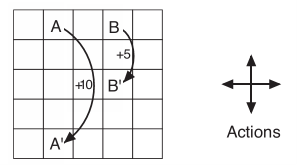

Consider a $5\times5$ Gridworld.

Each state has four actions:

$$
\mathcal{A}
=
\{\text{up},\text{down},\text{left},\text{right}\}.
$$

Rules:

- a normal move inside the grid gives reward $0$;
- attempting to move outside the grid leaves the agent in the same state and gives reward $-1$;
- from state $A$, every action gives reward $+10$ and moves to $A'$;
- from state $B$, every action gives reward $+5$ and moves to $B'$.

Use

$$
A=(0,1),\qquad A'=(4,1),
$$

$$
B=(0,3),\qquad B'=(2,3).
$$

The agent follows the equiprobable random policy

$$
\boxed{
\pi(a|s)=\frac14
}
$$

and

$$
\gamma=0.9.
$$

Because transitions are deterministic after choosing an action, the Bellman expectation equation simplifies to

$$
\boxed{
v_\pi(s)
=
\frac14
\sum_{a\in\mathcal{A}}
\left[
r(s,a)+\gamma v_\pi(s')
\right].
}
$$

In [ ]:
n_rows = 5
n_cols = 5
gamma = 0.9

actions = {
    "up": (-1, 0),
    "down": (1, 0),
    "left": (0, -1),
    "right": (0, 1)
}

A = (0, 1)
A_prime = (4, 1)
B = (0, 3)
B_prime = (2, 3)

def grid_step(state, action):
    if state == A:
        return A_prime, 10
    if state == B:
        return B_prime, 5

    row, col = state
    dr, dc = actions[action]
    nr, nc = row + dr, col + dc

    if nr < 0 or nr >= n_rows or nc < 0 or nc >= n_cols:
        return state, -1

    return (nr, nc), 0

V_pi = np.zeros((n_rows, n_cols))
theta = 1e-10

while True:
    new_V = np.zeros_like(V_pi)

    for row in range(n_rows):
        for col in range(n_cols):
            state = (row, col)
            value = 0.0

            for action in actions:
                next_state, reward = grid_step(state, action)
                nr, nc = next_state
                value += 0.25 * (reward + gamma * V_pi[nr, nc])

            new_V[row, col] = value

    if np.max(np.abs(new_V - V_pi)) < theta:
        V_pi = new_V
        break

    V_pi = new_V

print(np.round(V_pi, 1))

[[ 3.3  8.8  4.4  5.3  1.5]
 [ 1.5  3.   2.3  1.9  0.5]
 [ 0.1  0.7  0.7  0.4 -0.4]
 [-1.  -0.4 -0.4 -0.6 -1.2]
 [-1.9 -1.3 -1.2 -1.4 -2. ]]


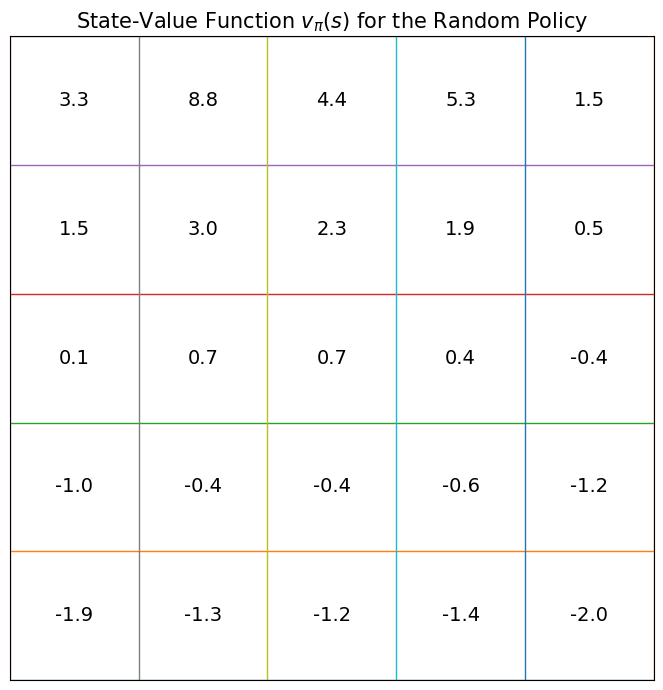

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect("equal")

for i in range(n_rows + 1):
    ax.plot([0, n_cols], [i, i], linewidth=1)
for j in range(n_cols + 1):
    ax.plot([j, j], [0, n_rows], linewidth=1)

for row in range(n_rows):
    for col in range(n_cols):
        x = col + 0.5
        y = n_rows - row - 0.5
        ax.text(x, y, f"{V_pi[row, col]:.1f}", ha="center", va="center", fontsize=14)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(r"State-Value Function $v_\pi(s)$ for the Random Policy", fontsize=15)
plt.tight_layout()
plt.show()

## Manual Bellman calculations in the Gridworld

### State $A$

Every action from $A$ gives reward $+10$ and moves to $A'$:

$$
v_\pi(A)
=
\sum_a
\frac14
\left[
10+\gamma v_\pi(A')
\right].
$$

All four terms are identical:

$$
v_\pi(A)
=
4\left(\frac14\right)
\left[
10+\gamma v_\pi(A')
\right].
$$

Hence,

$$
\boxed{
v_\pi(A)
=
10+\gamma v_\pi(A')
}
$$

Using approximately

$$
v_\pi(A')=-1.3
$$

and $\gamma=0.9$,

$$
v_\pi(A)
\approx
10+0.9(-1.3)
=
8.83
\approx
8.8.
$$

### State $B$

Similarly,

$$
\boxed{
v_\pi(B)
=
5+\gamma v_\pi(B')
}
$$

and because

$$
v_\pi(B')\approx0.4,
$$

$$
v_\pi(B)
\approx
5+0.9(0.4)
=
5.36
\approx
5.3.
$$

This illustrates that a state's value depends on both immediate reward and future state values.

In [ ]:
# Calculate action-value function Q_pi(s,a)

action_names = list(actions.keys())
Q_pi = np.zeros((n_rows, n_cols, len(action_names)))

for row in range(n_rows):
    for col in range(n_cols):
        state = (row, col)

        for i, action in enumerate(action_names):
            next_state, reward = grid_step(state, action)
            nr, nc = next_state

            Q_pi[row, col, i] = reward + gamma * V_pi[nr, nc]

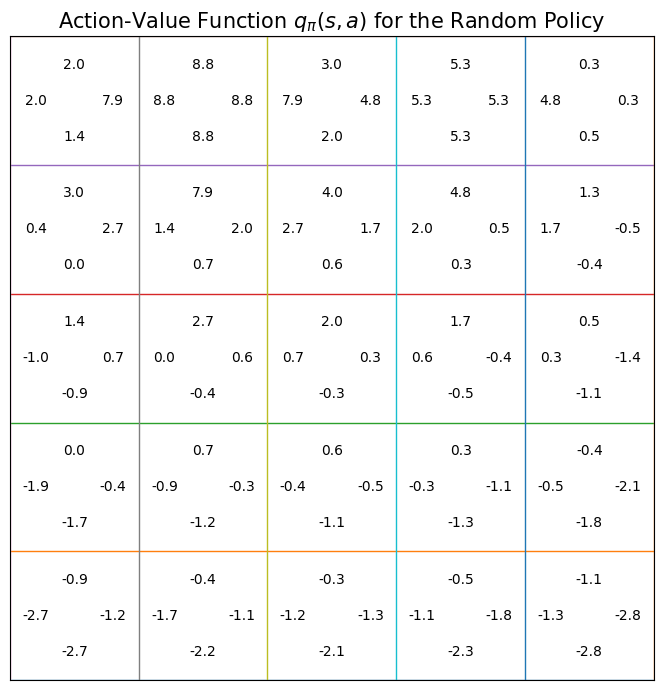

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect("equal")

for i in range(n_rows + 1):
    ax.plot([0, n_cols], [i, i], linewidth=1)

for j in range(n_cols + 1):
    ax.plot([j, j], [0, n_rows], linewidth=1)

action_positions = {
    "up": (0, 0.28),
    "down": (0, -0.28),
    "left": (-0.30, 0),
    "right": (0.30, 0)
}

for row in range(n_rows):
    for col in range(n_cols):

        x = col + 0.5
        y = n_rows - row - 0.5

        for i, action in enumerate(action_names):
            dx, dy = action_positions[action]

            ax.text(
                x + dx,
                y + dy,
                f"{Q_pi[row, col,i]:.1f}",
                ha="center",
                va="center",
                fontsize=10
            )

ax.set_xticks([])
ax.set_yticks([])

ax.set_title(
    r"Action-Value Function $q_\pi(s,a)$ for the Random Policy",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Manual Calculation of Action Values

For this Gridworld, the transition after choosing an action is deterministic. Therefore, the action-value function simplifies to

$$
\boxed{
q_\pi(s,a)
=
r(s,a)
+
\gamma v_\pi(s')
}
$$

where $s'$ is the next state reached after taking action $a$.

Consider the top-left state. Its state value is approximately

$$
v_\pi(s)=3.3
$$

and the discount factor is

$$
\gamma=0.9.
$$

For the **up** action, the agent attempts to leave the grid, so it stays in the same state and receives reward $-1$:

$$
q_\pi(s,\text{up})
=
-1+0.9(3.3)
=
1.97
\approx2.0.
$$

For the **left** action, the same thing happens:

$$
q_\pi(s,\text{left})
=
-1+0.9(3.3)
=
1.97
\approx2.0.
$$

For the **right** action, the agent moves to state $A$, whose value is approximately

$$
v_\pi(A)=8.8.
$$

The immediate reward is $0$, so

$$
q_\pi(s,\text{right})
=
0+0.9(8.8)
=
7.92
\approx7.9.
$$

For the **down** action, the agent moves to the state below, whose value is approximately

$$
1.5.
$$

Therefore,

$$
q_\pi(s,\text{down})
=
0+0.9(1.5)
=
1.35
\approx1.4.
$$

Thus, the action values for the top-left state are

$$
\boxed{
\begin{aligned}
q_\pi(s,\text{up}) &= 2.0,\\
q_\pi(s,\text{down}) &= 1.4,\\
q_\pi(s,\text{left}) &= 2.0,\\
q_\pi(s,\text{right}) &= 7.9.
\end{aligned}
}
$$

Since the policy selects all four actions with equal probability,

$$
\pi(a|s)=\frac14,
$$

the state value is the average of the four action values:

$$
v_\pi(s)
=
\frac14
\left(
2.0+1.4+2.0+7.9
\right)
=
3.325
\approx3.3.
$$

Therefore,

$$
\boxed{
v_\pi(s)
=
\sum_a \pi(a|s)q_\pi(s,a)
}
$$

so the state value is the policy-weighted average of the action values.

# 19. Bellman Optimality Equation

Start with

$$
v_*(s)
=
\max_a q_*(s,a).
$$

Substitute the one-step expression for $q_*$:

$$
v_*(s)
=
\max_a
\mathbb{E}
\left[
R_{t+1}
+
\gamma v_*(S_{t+1})
\mid
S_t=s,A_t=a
\right].
$$

Expand the expectation over all possible next states and rewards:

$$
\boxed{
v_*(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma v_*(s')
\right]
}
$$

This is the **Bellman optimality equation for $v_*$**.

For the action-value function,

$$
q_*(s,a)
=
\mathbb{E}
\left[
R_{t+1}
+
\gamma
\max_{a'}q_*(S_{t+1},a')
\mid
S_t=s,A_t=a
\right].
$$

Expanding the expectation gives

$$
\boxed{
q_*(s,a)
=
\sum_{s',r}
p(s',r|s,a)
\left[
r
+
\gamma
\max_{a'}
q_*(s',a')
\right].
}
$$

Once $q_*$ is known, an optimal policy is obtained by

$$
\boxed{
\pi_*(s)
\in
\arg\max_a q_*(s,a).
}
$$

If several actions tie for the maximum, all of them are optimal.

## Bellman expectation vs Bellman optimality

For a fixed policy,

$$
\boxed{
v_\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s',r}
p(s',r|s,a)
[r+\gamma v_\pi(s')]
}
$$

For optimal control,

$$
\boxed{
v_*(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
[r+\gamma v_*(s')]
}
$$

The key change is

$$
\boxed{
\sum_a \pi(a|s)
\quad\longrightarrow\quad
\max_a
}
$$

Policy evaluation averages according to the current policy. Optimal control selects the action with the largest expected return.

# Worked Example 4: Solving the Gridworld Optimally

Use the same $5\times5$ Gridworld, but now compute the best achievable value in every state.

Because the transition after selecting an action is deterministic,

$$
\boxed{
v_*(s)
=
\max_{a\in\mathcal{A}}
\left[
r(s,a)+\gamma v_*(s')
\right].
}
$$

The corresponding optimal policy is

$$
\boxed{
\pi_*(s)
\in
\arg\max_{a\in\mathcal{A}}
\left[
r(s,a)+\gamma v_*(s')
\right].
}
$$

In [ ]:
V_star = np.zeros((n_rows, n_cols))
theta = 1e-10
iterations = 0

while True:
    delta = 0.0
    new_V = np.copy(V_star)

    for row in range(n_rows):
        for col in range(n_cols):
            state = (row, col)
            action_returns = []

            for action in actions:
                next_state, reward = grid_step(state, action)
                nr, nc = next_state
                action_returns.append(reward + gamma * V_star[nr, nc])

            new_V[row, col] = max(action_returns)
            delta = max(delta, abs(new_V[row, col] - V_star[row, col]))

    V_star = new_V
    iterations += 1

    if delta < theta:
        break

print(f"Converged in {iterations} iterations")
print(np.round(V_star, 1))

Converged in 242 iterations
[[22.  24.4 22.  19.4 17.5]
 [19.8 22.  19.8 17.8 16. ]
 [17.8 19.8 17.8 16.  14.4]
 [16.  17.8 16.  14.4 13. ]
 [14.4 16.  14.4 13.  11.7]]


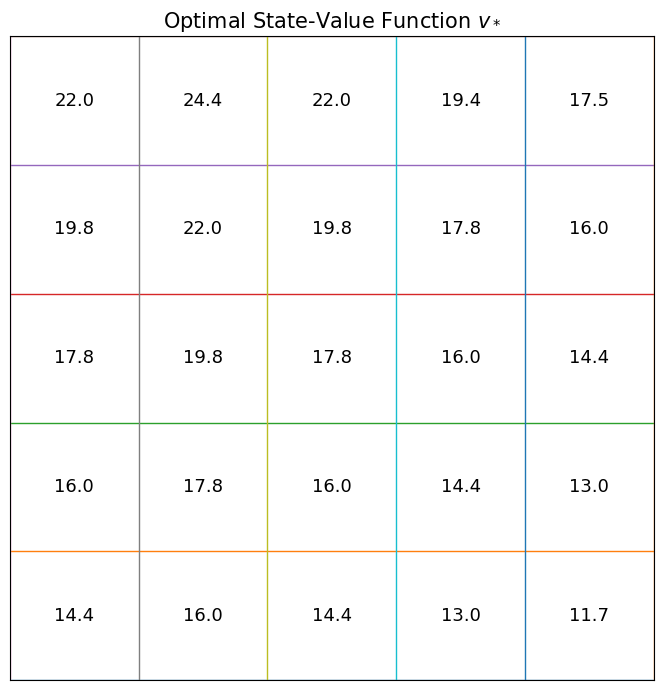

In [ ]:
optimal_policy = [[[] for _ in range(n_cols)] for _ in range(n_rows)]

for row in range(n_rows):
    for col in range(n_cols):
        state = (row, col)
        action_values = {}

        for action in actions:
            next_state, reward = grid_step(state, action)
            nr, nc = next_state
            action_values[action] = reward + gamma * V_star[nr, nc]

        best_value = max(action_values.values())

        for action, value in action_values.items():
            if np.isclose(value, best_value):
                optimal_policy[row][col].append(action)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect("equal")

for i in range(n_rows + 1):
    ax.plot([0, n_cols], [i, i], linewidth=1)
for j in range(n_cols + 1):
    ax.plot([j, j], [0, n_rows], linewidth=1)

for row in range(n_rows):
    for col in range(n_cols):
        x = col + 0.5
        y = n_rows - row - 0.5
        ax.text(x, y, f"{V_star[row, col]:.1f}", ha="center", va="center", fontsize=13)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(r"Optimal State-Value Function $v_*$", fontsize=15)
plt.tight_layout()
plt.show()

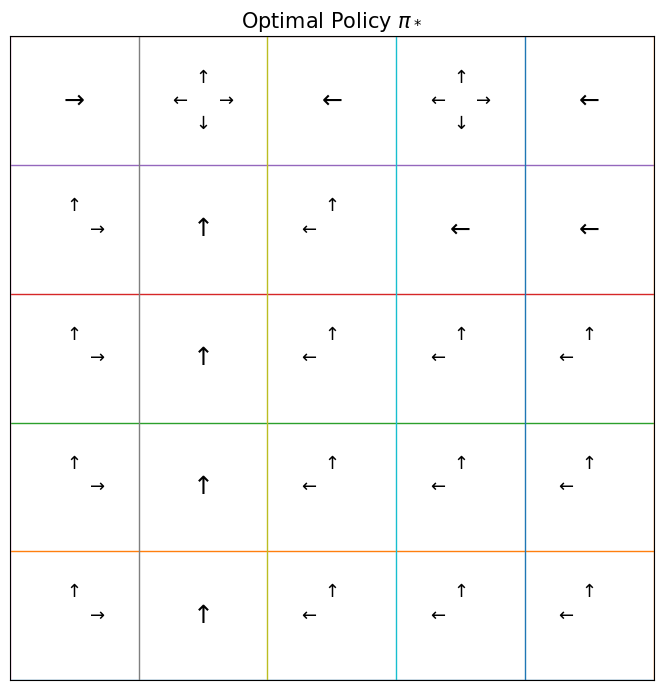

In [ ]:
symbols = {"up": "↑", "down": "↓", "left": "←", "right": "→"}
offsets = {
    "up": (0, 0.18),
    "down": (0, -0.18),
    "left": (-0.18, 0),
    "right": (0.18, 0)
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect("equal")

for i in range(n_rows + 1):
    ax.plot([0, n_cols], [i, i], linewidth=1)
for j in range(n_cols + 1):
    ax.plot([j, j], [0, n_rows], linewidth=1)

for row in range(n_rows):
    for col in range(n_cols):
        x = col + 0.5
        y = n_rows - row - 0.5
        acts = optimal_policy[row][col]

        if len(acts) == 1:
            ax.text(x, y, symbols[acts[0]], ha="center", va="center", fontsize=18)
        else:
            for act in acts:
                dx, dy = offsets[act]
                ax.text(x + dx, y + dy, symbols[act], ha="center", va="center", fontsize=13)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(r"Optimal Policy $\pi_*$", fontsize=15)
plt.tight_layout()
plt.show()

 Manual Bellman optimality calculations

### State $A$

Every action from $A$ gives reward $+10$ and moves to $A'$:

$$
v_*(A)
=
10+\gamma v_*(A').
$$

Using approximately

$$
v_*(A')=16.0
$$

and $\gamma=0.9$,

$$
v_*(A)
=
10+0.9(16.0)
=
\boxed{24.4}.
$$

### State $B$

Similarly,

$$
v_*(B)
=
5+\gamma v_*(B').
$$

Using

$$
v_*(B')=16.0,
$$

$$
v_*(B)
=
5+0.9(16.0)
=
\boxed{19.4}.
$$

### Top-left state $(0,0)$

Four actions are available.

For `up` and `left`, the agent attempts to leave the grid:

$$
q_*\big((0,0),\text{up}\big)
=
-1+0.9v_*(0,0),
$$

$$
q_*\big((0,0),\text{left}\big)
=
-1+0.9v_*(0,0).
$$

For `right`:

$$
q_*\big((0,0),\text{right}\big)
=
0+0.9v_*(0,1).
$$

For `down`:

$$
q_*\big((0,0),\text{down}\big)
=
0+0.9v_*(1,0).
$$

Using

$$
v_*(0,0)=22.0,\qquad
v_*(0,1)=24.4,\qquad
v_*(1,0)=19.8,
$$

the one-step action values are approximately

$$
-1+0.9(22.0)=18.8,
$$

$$
0.9(24.4)=21.96,
$$

$$
0.9(19.8)=17.82.
$$

Therefore,

$$
v_*(0,0)
=
\max\{18.8,18.8,21.96,17.82\}
\approx
\boxed{22.0},
$$

and the optimal action is `right`.

# 20. Core Mathematical Relationships

The central equations of a finite MDP can be summarized as follows.

### Dynamics

$$
p(s',r|s,a)
=
P(S_{t+1}=s',R_{t+1}=r\mid S_t=s,A_t=a)
$$

### State-transition probability

$$
p(s'|s,a)
=
\sum_r p(s',r|s,a)
$$

### Expected reward

$$
r(s,a)
=
\sum_{s',r}r\,p(s',r|s,a)
$$

### Return

$$
G_t
=
\sum_{k=0}^{\infty}\gamma^kR_{t+k+1}
$$

### Recursive return

$$
G_t
=
R_{t+1}+\gamma G_{t+1}
$$

### Policy

$$
\pi(a|s)
=
P(A_t=a\mid S_t=s)
$$

### State value

$$
v_\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s]
$$

### Action value

$$
q_\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
$$

### Bellman expectation equation

$$
v_\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s',r}
p(s',r|s,a)
[r+\gamma v_\pi(s')]
$$

### Optimal state value

$$
v_*(s)=\max_\pi v_\pi(s)
$$

### Optimal action value

$$
q_*(s,a)=\max_\pi q_\pi(s,a)
$$

### Bellman optimality equation

$$
v_*(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
[r+\gamma v_*(s')]
$$

### Optimal policy

$$
\pi_*(s)\in\arg\max_a q_*(s,a)
$$

## 21. Model-Based vs. Model-Free Methods

The MDP describes the decision problem. A learning algorithm can use it in different ways.

### Model-based

The agent has or learns a model of

$$
P(s'|s,a)
$$

and possibly

$$
R(s,a,s')
$$

and uses the model for planning.

Because the transition model is available, the agent can often use the **state-value function**

$$
V(s)
$$

and combine it with the model to evaluate possible actions.

### Model-free

The agent does not need an explicit transition model. It can learn values or policies directly from experience.

For **model-free value-based control**, the **action-value function**

$$
Q(s,a)
$$

is especially useful because it directly tells the agent how good each action is in a state. The agent can then choose

$$
a^*=\arg\max_a Q(s,a)
$$

without knowing

$$
P(s'|s,a).
$$

So the key idea is:

$$
\boxed{
\text{Model-based: model + } V(s) \text{ can be used to evaluate actions}
}
$$

$$
\boxed{
\text{Model-free value-based control: } Q(s,a) \text{ can be used to choose actions directly}
}
$$

This is not a strict rule: model-based methods can also use $Q(s,a)$, and model-free methods can also learn $V(s)$.

Examples of model-free methods include:

- Monte Carlo methods
- SARSA
- Q-learning
- policy-gradient methods

The environment can be deterministic or stochastic in either case.

## Fully Observable MDP vs. POMDP

A fully observable MDP assumes that the agent can observe all the information needed to describe the current state and satisfy the Markov property.

Examples include:

- **Chess:** the complete board configuration is visible, including the positions of all pieces.
- **GridWorld:** the agent can observe its current location and the relevant environment layout.

If the true state of the environment is not completely observable, the problem may instead be modeled as a **Partially Observable Markov Decision Process (POMDP)**.

For example, an **autonomous vehicle** cannot observe the complete environment directly. Its cameras and other sensors can only observe part of the surroundings. Some vehicles, pedestrians, road conditions, or objects may be outside the camera view or hidden by other objects.

Therefore, the vehicle receives an **observation** of the environment rather than the complete underlying state.

A POMDP extends an MDP by including observations and an observation model. The agent may need to maintain a **belief** about the possible true states of the environment.

$$
\boxed{
\text{MDP: agent observes the state}
}
$$

$$
\boxed{
\text{POMDP: agent observes only partial information about the state}
}
$$

##  Designing an MDP

When defining a decision problem, ask:

### State
What information must the agent know to make future decisions?

### Action
What decisions can the agent actually control?

### Transition
What happens after an action? Is the transition deterministic or stochastic?

### Reward
What immediate behavior should be encouraged or penalized?

### Terminal condition
When does an episode end?

### Discount factor
How much should future rewards matter?

### Initial state
Where can an episode begin?

These choices define the mathematical problem before any RL algorithm is selected.

# 22. Key Takeaways

A finite MDP provides a mathematical description of sequential decision making under uncertainty.

The main progression is

$$
\boxed{
\text{state}
\rightarrow
\text{action}
\rightarrow
\text{reward and next state}
\rightarrow
\text{return}
\rightarrow
\text{value}
\rightarrow
\text{optimal decision}
}
$$

The Bellman equations connect immediate outcomes to future value. They are the mathematical foundation for the next group of methods:

- policy evaluation,
- policy improvement,
- policy iteration,
- value iteration,
- Monte Carlo methods,
- temporal-difference learning,
- Q-learning and related control algorithms.

The next logical portfolio topic is **Dynamic Programming for Finite MDPs**.